# Comparing Models for Daily Rat Sightings in New York City

## Import packages

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance


## Importing the Data

In [3]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

## Baseline Seasonal Average Model

In [4]:
years_back_use = 4
day_window_use = 4

In [5]:
def seasonal_average_forecast(data, target_dates, years_back=years_back_use, day_window=day_window_use):
    df = data.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    df["doy"] = df["ds"].dt.dayofyear
    df["year"] = df["ds"].dt.year

    forecasts = []
    for target_date in target_dates:
        target_doy = target_date.dayofyear
        target_year = target_date.year
        mask = ((df["year"] >= target_year - years_back) & (df["year"] < target_year) & (np.abs(df["doy"] - target_doy) <= day_window))
        forecasts.append(df.loc[mask, "y"].mean())
    return pd.Series(forecasts, index=target_dates)

In [6]:
results = []
rs["ds"] = pd.to_datetime(rs["ds"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["ds"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a day_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, 
                                       target_dates=target_dates, 
                                       years_back=years_back_use,
                                       day_window=day_window_use)

    # We take the true values.
    y_true = test["y"].values
    
    # Compute the metrics
    y_pred = np.round(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
baseline_results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
baseline_results_df.loc["mean"] = ["mean", baseline_results_df["rmse"].mean(), baseline_results_df["mape"].mean()]

baseline_results_df

,fold,rmse,mape
0,0,18.687276,0.253690
1,1,11.707751,0.201007
2,2,13.071233,0.220691
3,3,21.375888,0.237572
4,4,19.539338,0.180911
5,5,27.059458,0.256567
6,6,22.853571,0.216644
7,7,23.584196,0.239873
8,8,15.508062,0.210285
9,9,18.740712,0.207144


## Baseline Year Ago Rolling 4 Week Average 

In [7]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

## Just saving a copy for later
rs_saved = rs.copy()

In [8]:
# Tired of writing np.sqrt or typing a long name.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []

for fold, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]

    # Calculate the 4-week rolling average for the training data
    train_sorted = train.sort_values('ds') # making sure to sort it by date
    train_sorted['rolling_4w'] = train_sorted['y'].rolling(window=4, min_periods=1).mean()

    # This part of the code makes the predictions. We use the 'rolling_4w' column of the training set.
    y_pred = []
    y_true = test['y'].values

    for idx, row in test.iterrows():
        # Predict using the latest rolling average from the train data
        prediction = train_sorted['rolling_4w'].iloc[-1]  # Last value in the train rolling avg
        y_pred.append(prediction)
        
    # Calculate RMSE and MAPE for this fold
    y_pred = np.round(y_pred)
    fold_rmse = rmse(y_true, y_pred)
    fold_mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': fold, 'rmse': fold_rmse, 'mape': fold_mape})

rolling4w_results_df = pd.DataFrame(results)

overall_rmse = rolling4w_results_df['rmse'].mean()
overall_mape = rolling4w_results_df['mape'].mean()
rolling4w_results_df.loc['mean'] = ['mean', overall_rmse, overall_mape]
rolling4w_results_df

,fold,rmse,mape
0,0,15.558645,0.245443
1,1,20.596463,0.388633
2,2,14.232759,0.250932
3,3,19.568561,0.225221
4,4,16.496753,0.175667
5,5,20.984688,0.237765
6,6,29.028311,0.361794
7,7,27.988518,0.338598
8,8,18.104853,0.241760
9,9,25.520300,0.233672


## Prophet Model

In [9]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

In [10]:
date_range = pd.date_range(start="2020-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

In [11]:
# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_pred = np.round(y_pred)
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]
prophet_results_df

09:55:02 - cmdstanpy - INFO - Chain [1] start processing
09:55:03 - cmdstanpy - INFO - Chain [1] done processing
09:55:04 - cmdstanpy - INFO - Chain [1] start processing
09:55:04 - cmdstanpy - INFO - Chain [1] done processing
09:55:05 - cmdstanpy - INFO - Chain [1] start processing
09:55:05 - cmdstanpy - INFO - Chain [1] done processing
09:55:06 - cmdstanpy - INFO - Chain [1] start processing
09:55:07 - cmdstanpy - INFO - Chain [1] done processing
09:55:08 - cmdstanpy - INFO - Chain [1] start processing
09:55:08 - cmdstanpy - INFO - Chain [1] done processing
09:55:09 - cmdstanpy - INFO - Chain [1] start processing
09:55:09 - cmdstanpy - INFO - Chain [1] done processing
09:55:10 - cmdstanpy - INFO - Chain [1] start processing
09:55:10 - cmdstanpy - INFO - Chain [1] done processing
09:55:12 - cmdstanpy - INFO - Chain [1] start processing
09:55:12 - cmdstanpy - INFO - Chain [1] done processing
09:55:14 - cmdstanpy - INFO - Chain [1] start processing
09:55:14 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,11.470459,0.156538
1,1,12.674496,0.209585
2,2,10.406042,0.147927
3,3,14.667749,0.144359
4,4,13.314868,0.122128
5,5,18.357560,0.175779
6,6,14.774495,0.138124
7,7,13.236853,0.123056
8,8,13.352367,0.181920
9,9,11.193110,0.125593


## NeuralProphet Model

Since the Prophet model seemed to work so well (see below), we might ask about whether or not one cna improve on it. We try the ['Neural Prophet model'](https://neuralprophet.com/) which should theoretically provide the either the same results or improvements.

Edit: This section is currently commented out and comparisons will be done in another notebook. This is to speed up run time fo this notebook.

In [12]:
# # this is the time series split we will work with
# tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# # we import the data and clean it for future use
# rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
# rs['created_date'] = pd.to_datetime(rs['created_date']) 
# # mark cutoff dates, and also rename columns
# rs = rs[rs['created_date']<'2025-03-01']
# rs = rs[rs['created_date']>='2020-01-01']
# rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
# rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

In [13]:
# from neuralprophet import NeuralProphet

# import numpy as np
# np.NaN = np.nan


# # the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# # the errors that do show up are not all that important and a lot is due to outdated packages.
# import warnings
# import logging

# warnings.filterwarnings("ignore")

# logging.getLogger("neuralprophet").setLevel(logging.ERROR)
# logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
# logging.getLogger("NP").setLevel(logging.ERROR)

In [14]:
# ## Add weather data.

# import requests
# import pandas as pd

# lat, lon = 40.7831, -73.9712
# start = "2020-01-01"
# end   = "2025-02-28" # <"2025-03-01"

# url = (
#     "https://archive-api.open-meteo.com/v1/archive"
#     f"?latitude={lat}&longitude={lon}"
#     f"&start_date={start}&end_date={end}"
#     "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
#     "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
#     "precipitation_sum,snowfall_sum"
#     "&timezone=America/New_York"
# )

# response = requests.get(url)
# data = response.json()

# if 'error' in data:
#     nd = pd.read_csv("weatherdata.csv")
#     nd = nd.set_index('date')
#     wd = nd
    
# else:
#     wd = pd.DataFrame(data["daily"])
#     wd["date"] = pd.to_datetime(wd["time"])
#     wd = wd.set_index("date")

# def add_weather_data_no_index(df,wd):
#     if "time" in wd.columns:
#         wd = wd.drop(columns=["time"])

#     for column in wd.columns:
#         df[column] = wd[column].values

#     return df

In [15]:
# regressed_features = ['apparent_temperature_max', 
#                       'apparent_temperature_min',
#                     'snowfall_sum']
# wd = wd.reset_index(drop=True).rename(columns={"time": "ds"})
# wd["ds"] = pd.to_datetime(wd["ds"])
# rs["ds"] = pd.to_datetime(rs["ds"])

# rs = rs.merge(
#     wd[['ds'] + regressed_features],
#     on="ds",
#     how="left"
# )

# lags_for_regressed_features = dict()
# lags_for_regressed_features['apparent_temperature_max'] = 30
# lags_for_regressed_features['apparent_temperature_min'] = 14
# lags_for_regressed_features['snowfall_sum'] = 3

In [16]:
# results = []

# for i, (train_index, test_index) in enumerate(tscv.split(rs)):

#     train = rs.iloc[train_index].copy()
#     test = rs.iloc[test_index].copy()

#     train = train.dropna(subset=["y"])


#     model = NeuralProphet(yearly_seasonality=True, 
#                           #weekly_seasonality=True, 
#                           epochs = 25,
#                           accelerator = 'auto',
#                           n_lags=7)

#     model = model.add_country_holidays(country_name="US")

#     for column in regressed_features:
#         model.add_lagged_regressor(column, n_lags=lags_for_regressed_features[column])

#     # merge regressors correctly
#     # train = train.merge(wd[['ds'] + regressed_features], on="ds", how="left")

#     model.fit(train, freq="D", progress="off")

#     # build dataframe containing future regressors
#     future = pd.concat([train[['ds','y'] + regressed_features], test[['ds','y']].merge(wd[['ds'] + regressed_features], on="ds", how="left")])
#     forecast = model.predict(future)

#     y_pred = forecast["yhat1"].iloc[-len(test):].values
#     y_true = test["y"].values

#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mape = mean_absolute_percentage_error(y_true, y_pred)

#     results.append({"fold": i, "rmse": rmse, "mape": mape})

# neural_prophet_results_df = pd.DataFrame(results)
# neural_prophet_results_df.loc["mean"] = ["mean", neural_prophet_results_df["rmse"].mean(), neural_prophet_results_df["mape"].mean()]
# neural_prophet_results_df

## SARIMAX Model

The reason why the SARIMA / SARIMAX model does not perform as well as we'd like is discussed here: https://stats.stackexchange.com/questions/613677/using-sarimax-for-daily-data-with-yearly-seasonal-pattern. An excellent read for more details can be found here: https://robjhyndman.com/hyndsight/longseasonality/. For these reasons, instead of using SARIMA's included seasonality features for the yearly seasonality, we instead add Fourier terms as exogeneous variables. Furthermore, we make the point that ARIMA is only good over a short interval. Since our goal is 14 days out, as opposed to 7 days, the predictions are not as good.

In [17]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [18]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

In [19]:
def fourier_terms(df, periods, n_terms):
    t = np.arange(1, len(df) + 1)
    fourier_df = pd.DataFrame()
    
    for period in periods:
        for i in range(1, n_terms + 1):
            fourier_df[f'{period}sin_{i}'] = np.sin(2 * np.pi * i * t / period)
            fourier_df[f'{period}cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    
    return fourier_df

fourier_train = fourier_terms(rs, [365], 10)
exog = fourier_train

In [20]:
results = []

# Loop through each fold
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]

    exog_train = exog.iloc[train_index]
    exog_test = exog.iloc[test_index]

    orders = (2,1,1)
    seasonal_orders = (1,0,1,7)

    # we can use auto_arima to get optimal (p, d, q) and (P, D, Q, s) parameters for SARIMAX. just need to uncomment the following code.
    # model_auto = auto_arima(train['y'], 
    #                         exog=exog_train,  # exogenous Fourier terms for training data
    #                         seasonal=True, 
    #                         m=7, #  
    #                         trace=True, 
    #                         stepwise=True,  # Stepwise search to speed up
    #                         suppress_warnings=True, 
    #                         maxiter=300,  # Limit the number of iterations
    #                         max_p=3, 
    #                         max_q=3, 
    #                         max_P=2, 
    #                         max_Q=2, 
    #                         d=1,# might want to tune d 
    #                         D=1 # might want to tune D
    #                         )
    # orders = model_auto.order  # (p, d, q)
    # seasonal_orders = model_auto.seasonal_order  # (P, D, Q, s)
    
    # Fit the SARIMAX model with the exogenous features (Fourier terms)
    model_sarimax = SARIMAX(train['y'], 
                            order=orders,  
                            seasonal_order=seasonal_orders,  
                            exog=exog_train,  # Exogenous Fourier terms for training data
                            )
    
    model_fit = model_sarimax.fit(disp=False)
    
    # Predict for the test period. Have to remember to subtract 1 to get the correct index.
    y_pred = model_fit.predict(start=len(train), end=len(train)+len(test)-1, exog=exog_test, dynamic=False)
    y_pred = np.round(y_pred)
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

sarima_results_df = pd.DataFrame(results)
sarima_results_df.loc['mean'] = ['mean',  sarima_results_df['rmse'].mean(), sarima_results_df['mape'].mean()]
sarima_results_df

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('No

,fold,rmse,mape
0,0,10.753737,0.148654
1,1,14.684783,0.270352
2,2,10.285218,0.168201
3,3,17.543823,0.177677
4,4,11.735173,0.111508
5,5,17.425351,0.168221
6,6,18.413892,0.223525
7,7,17.697861,0.200035
8,8,18.343936,0.233774
9,9,13.155661,0.110919


## Holt-Winters Model

In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [22]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

In [23]:
results = []
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    holt_winters = ExponentialSmoothing(train['y'], seasonal='add', seasonal_periods=365).fit(optimized=True)
    
    y_pred = holt_winters.forecast(len(test))
    y_true = test['y'].values
    y_pred = np.round(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

hw_results_df = pd.DataFrame(results)
hw_results_df.loc['mean'] = ['mean',  hw_results_df['rmse'].mean(), hw_results_df['mape'].mean()]
hw_results_df

,fold,rmse,mape
0,0,18.535680,0.283097
1,1,19.714027,0.356570
2,2,17.237832,0.290284
3,3,20.452034,0.221044
4,4,19.960676,0.203189
5,5,24.285504,0.246944
6,6,31.772630,0.352029
7,7,27.027764,0.305535
8,8,27.640550,0.392118
9,9,25.788979,0.293892


## MSTL Model

MSTL Model stands for Multiple Seasonal-Trend decomposition using LOESS. For more, see https://nixtlaverse.nixtla.io/statsforecast/docs/models/multipleseasonaltrend.html.

*If the code in this section is currently commented out and one wants to see the results, then one should uncomment and make sure to edit the results table below to include the results of this run.*

In [24]:
# !pip install statsforecast

In [25]:
# from statsforecast import StatsForecast
# from statsforecast.models import MSTL, AutoARIMA

In [26]:
# tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

# # again, we reimport the data for ease of running

# rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
# rs['created_date'] = pd.to_datetime(rs['created_date']) 
# rs['closed_date'] = pd.to_datetime(rs['closed_date'])
# rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# # mark cutoff dates, and also rename columns
# rs = rs[rs['created_date']<'2025-03-01']
# rs = rs[rs['created_date']>='2020-01-01']
# rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
# rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# # This is should be 2251 which equals the number of days from 2020-01-01 to 2026-02-28
# print(len(rs)==2251)


In [27]:
# # specific to Statsforecast requirements

# rs.columns = ['ds', 'y']
# rs.insert(0, 'unique_id', 'DAILY_RAT_SIGHTINGS')
# rs = rs.sort_values(['unique_id', 'ds']).reset_index(drop=True)
# rs.tail()

In [28]:
# rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# results = []

# def create_dataset(series, time_step=1):
#     X, y = [], []
#     for i in range(len(series) - time_step):
#         X.append(series[i:(i + time_step), 0])
#         y.append(series[i + time_step, 0])
#     return np.array(X), np.array(y)

# time_step = 10
# results = []

# for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
#     train = rs.iloc[train_index]
#     test = rs.iloc[test_index]

#     series = train['y'].values

#     # scale the data
#     models = [MSTL(
#     season_length=[7, 7*4, 7*52], # seasonalities of the time series (weekly, monthly, yearly)
#     trend_forecaster=AutoARIMA() # model used to forecast trend
#     )]
#     sf = StatsForecast(
#     models=models, # model used to fit
#     freq='d', # frequency of the data
#     )

#     sf = sf.fit(df=rs)
#     forecasts = sf.predict(h=14, level=[90]) # 90 means (confidence percentile) of the prediction interval. 

#     y_pred = forecasts['MSTL'].values
#     y_true = test['y'].values

#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mape = mean_absolute_percentage_error(y_true, y_pred)

#     results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# mstl_results_df = pd.DataFrame(results)
# mstl_results_df.loc['mean'] = ['mean',  mstl_results_df['rmse'].mean(), mstl_results_df['mape'].mean()]
# mstl_results_df

## LSTM Model

LSTM stands for Long Term Short Memory. Here, we simply try to use the LSTM model by itself and check how it performs. For future purposes, it might be of interest to see if a ['hybrid model'](https://peerj.com/articles/cs-1001/#proposed-hybrid-model) using Prophet and LSTM might be able to produce better results.

If the code in this section is currently commented out and one wants to see the results, then one should uncomment and make sure to edit the results table below to include the results of this run.

In [29]:
# pip install neuralforecast

In [30]:
# from neuralforecast import NeuralForecast
# from neuralforecast.models import LSTM
# import pandas as pd
# import numpy as np

In [31]:
# tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

# # again, we reimport the data for ease of running

# rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
# rs['created_date'] = pd.to_datetime(rs['created_date']) 
# rs['closed_date'] = pd.to_datetime(rs['closed_date'])
# rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# # mark cutoff dates, and also rename columns
# rs = rs[rs['created_date']<'2025-03-01']
# rs = rs[rs['created_date']>='2020-01-01']
# rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
# rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# # This is should be 2251 which equals the number of days from 2020-01-01 to 2026-02-28
# print(len(rs)==2251)

# rs['ds'] = pd.to_datetime(rs['ds'])
# rs['ds'] = rs['ds'].astype('datetime64[ns]')

In [32]:
# time_step = 14
# results = []

# for i, (train_index, test_index) in enumerate(tscv.split(rs)):

#     train = rs.iloc[train_index].copy()
#     test = rs.iloc[test_index].copy()

#     # need to do some heavy formatting
#     train_df = train[['ds', 'y']].copy()
#     train_df['unique_id'] = 'series_1'
#     train_df = train_df[['unique_id', 'ds', 'y']]
#     test_df = test[['ds', 'y']].copy()
#     test_df['unique_id'] = 'series_1'
#     test_df = test_df[['unique_id', 'ds', 'y']]

#     horizon = len(test_df)

#     models = [LSTM(h=horizon, max_steps=100, scaler_type='standard')]
#     nf = NeuralForecast(models=models, freq='D')

#     nf.fit(df=train_df)
#     forecasts = nf.predict(h=14)

#     y_pred = forecasts['LSTM'].values
#     y_true = test_df['y'].values

#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mape = mean_absolute_percentage_error(y_true, y_pred)

#     results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# lstm_results_df = pd.DataFrame(results)
# lstm_results_df.loc['mean'] = ['mean',  lstm_results_df['rmse'].mean(), lstm_results_df['mape'].mean()]
# lstm_results_df

## XGBoost Model

The XGBoost model requires a bit more preparatory work. Our current dataframe rs is quite bare. We will need to add features for use.

In [33]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

### Adding Features to XGBoost

In [34]:
def create_features(df):
    # create time series features based on time series index.
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    # features to handly cyclic behavior
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    # lags
    target_map = df['y'].to_dict()
    df['lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    # lags of various lengths for different levels of seasonality
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    # Must shift by 14 days because we do not want to let there be temporal leakage in our evaluations
    df['ma7'] = df['y'].shift(14).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(14).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(14).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(14).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(14).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(14).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(14).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(14).rolling(window=365).mean()
    
    return df


In the next two code block, we add weather data to the data set. This is not optimized i.e. we just obtain the weather data in Manhattan and hope that it is representative of the average weather over the whole city.

In [35]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

In [36]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary columns
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Remove overlapping columns to avoid join errors
    overlap = wd.columns.intersection(df.columns)
    wd = wd.drop(columns=overlap)
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['apparent_temperature_min_lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['apparent_temperature_min_lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df['apparent_temperature_min_lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df['apparent_temperature_min_lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df['apparent_temperature_min_lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df['apparent_temperature_min_lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df['apparent_temperature_min_lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df

In [37]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format handling
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD format handling
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [38]:
def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

In [39]:
rs = rs.set_index('ds')
rs.index = pd.to_datetime(rs.index)

In [40]:
rs = create_features(rs)
rs = add_cyclic(rs)
rs = add_lags(rs)
rs = add_seasonal_lags(rs)
rs = add_moving_averages(rs)
rs = add_weather_data(rs,wd)
rs = add_more_weather_feature(rs)
rs = add_federal_holidays(rs, custom_holidays = ['12-31'])
rs = add_law_flag(rs, law_name='Trash_Law', start_date = '2024-03-01')
rs = add_law_flag(rs, law_name = 'New_Trash_Law', start_date = '2024-11-01')
rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

rs.columns

Index(['y', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth',
       'weekofyear', 'dayofweek_sin', 'dayofweek_cos', 'month_sin',
       'month_cos', 'lag15', 'lag16', 'lag30', 'lag60', 'lag90', 'lag120',
       'lag150', 'lag180', 'lag362', 'lag363', 'lag364', 'lag365', 'lag366',
       'lag367', 'lag730', 'lag1095', 'lag1460', 'lag1825', 'ma7', 'ma30',
       'ma60', 'ma90', 'ma120', 'ma150', 'ma180', 'ma365',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',
       'apparent_temperature_min_lag1', 'apparent_temperature_min_lag7',
       'apparent_temperature_min_lag14', 'apparent_temperature_min_lag15',
       'apparent_temperature_min_lag16', 'apparent_temperature_min_lag17',
       'apparent_temperature_min_lag18', 'apparent_temperature_min_lag19',
       'apparent_temperature_min_lag20', 'apparent_tempera

### Features for XGBoost

In [41]:
FEATURES = ['apparent_temperature_min_lag30',
            'apparent_temperature_min_lag60',
            'apparent_temperature_min_lag120',
            'apparent_temperature_min_lag365',
            'apparent_temperature_min_lag730',
            'dayofyear', 'temperature_2m_max_lag14', 'temperature_2m_max_lag30',
            'temperature_2m_max_lag60', 'is_federal_holiday', 
            'lag15', 'lag16', 
            'lag30', 'lag60', 'lag90', 'lag120',
            'lag150', 'lag180', 'lag362', 'lag363', 'lag364', 'lag365', 'lag366',
            'lag367',
            ]

### Parameters for XGBoost

In [42]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': 0.5, 
         'n_estimators': 1000, 
        #  'min_child_weight': 6, 
        # 'learning_rate': 0.001,
        # 'max_depth': 6, 
        # 'subsample': 1,
        # 'colsample_bytree': 0.96,
        # 'colsample_bylevel': 0.6, 
        # 'colsample_bynode': 0.9, 
        # 'reg_alpha': 2.2, 
        # 'gamma': 100, 
        # 'reg_lambda': 0.18,
        #  'early_stopping_rounds': 100, 
        }

### Results for XGBoost Model

In [43]:
# print(FEATURES)
# print(params)
TARGET = 'y'

# Gotta make sure the features and parameters exist.

reg = xgb.XGBRegressor(**params)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    reg.fit(train[FEATURES], train[TARGET])
    y_pred = reg.predict(test[FEATURES])
    y_true = test[TARGET].values
    y_pred = np.round(y_pred)
    # Our metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

xgb_results_df = pd.DataFrame(results)
mean_rmse = xgb_results_df['rmse'].mean()
mean_mape = xgb_results_df['mape'].mean()
xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

In [44]:
xgb_results_df

,fold,rmse,mape
0,0,17.932413,0.228580
1,1,24.034202,0.399935
2,2,18.996240,0.318595
3,3,18.543386,0.220469
4,4,15.734403,0.156992
5,5,21.658057,0.206597
6,6,20.650147,0.220162
7,7,22.754905,0.187570
8,8,22.870754,0.293086
9,9,14.372593,0.164214


## XGBoosted Prophet Model

In [45]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

In [46]:
def add_new_lags(df, x):
    # lags
    target_map = df[x].to_dict()
    df[f'{x}lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag16'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag17'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag18'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag19'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag20'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag21'] = (df.index - pd.Timedelta('16 days')).map(target_map)

    df[f'{x}lag30'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag365'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag730'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    return df

In [47]:
FEATURES = ['apparent_temperature_min_lag30',
            'apparent_temperature_min_lag60',
            'apparent_temperature_min_lag120',
            'apparent_temperature_min_lag365',
            'apparent_temperature_min_lag730',
            'dayofyear', 'temperature_2m_max_lag14', 'temperature_2m_max_lag30',
            'temperature_2m_max_lag60', 
            'is_federal_holiday', 
            'lag15', 'lag16', 'lag30', 'lag60', 'lag90', 'lag120', 'lag150', 
            'lag180', 
            'lag362', 'lag363', 'lag364', 'lag365', 'lag366', 'lag367',
            'residualslag15', 'residualslag16', 'residualslag17',
            'residualslag18', 'residualslag19', 'residualslag20', 'residualslag21',
            'residualslag30', 'residualslag365', 'residualslag730', 
            'trend', 'yhat_lower', 'yhat_upper', 
            ]

### Parameters for XGB+Prophet

In [48]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
        # 'base_score': 0.5, 
        # 'n_estimators': 2000, 
        #  'min_child_weight': 6, 
        # 'learning_rate': 0.01,
        # 'max_depth': 6, 
        # 'subsample': 1,
        # 'colsample_bytree': 0.96,
        # 'colsample_bylevel': 0.6, 
        # 'colsample_bynode': 0.9, 
        # 'reg_alpha': 2.2, 
        # 'gamma': 100, 
        # 'reg_lambda': 0.18,
        #  'early_stopping_rounds': 100, 
        }

In [49]:
date_range = pd.date_range(start="2020-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

In [50]:
save = rs['ds'].copy().values
rs = rs.set_index('ds')
rs.index = pd.to_datetime(rs.index)
rs['ds']=save
rs = create_features(rs)
rs = add_cyclic(rs)
rs = add_lags(rs)
rs = add_seasonal_lags(rs)
rs = add_moving_averages(rs)
rs = add_weather_data(rs,wd)
rs = add_more_weather_feature(rs)
rs = add_federal_holidays(rs, custom_holidays = ['12-31'])
rs = add_law_flag(rs, law_name='Trash_Law', start_date = '2024-03-01')
rs = add_law_flag(rs, law_name = 'New_Trash_Law', start_date = '2024-11-01')
rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')
rs

,y,ds,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,dayofweek_sin,...,apparent_temperature_min_lag365,apparent_temperature_min_lag730,temperature_2m_max_lag14,temperature_2m_max_lag30,temperature_2m_max_lag60,is_federal_holiday,Trash_Law,New_Trash_Law,Rat_Mitigation_Zone,Rat_Czar_Appointed
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-01,17,2020-01-01,2,1,1,2020,1,1,1,0.974928,...,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0
2020-01-02,40,2020-01-02,3,1,1,2020,2,2,1,0.433884,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-03,41,2020-01-03,4,1,1,2020,3,3,1,-0.433884,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-04,25,2020-01-04,5,1,1,2020,4,4,1,-0.974928,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-05,17,2020-01-05,6,1,1,2020,5,5,1,-0.781831,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-24,57,2025-02-24,0,1,2,2025,55,24,9,0.000000,...,-11.1,-10.8,0.2,-2.2,-0.2,0,1,1,1,1
2025-02-25,61,2025-02-25,1,1,2,2025,56,25,9,0.781831,...,-6.9,-8.1,-0.4,4.1,2.5,0,1,1,1,1
2025-02-26,61,2025-02-26,2,1,2,2025,57,26,9,0.974928,...,-4.1,-7.1,0.6,2.0,7.5,0,1,1,1,1


In [51]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    # Split the dataset into training and testing sets
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    # Fit Prophet on the training data
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)
    
    # Make predictions on the training set to calculate residuals
    train_future = model.make_future_dataframe(periods=0, freq='D')  # Use periods=0 to only use the training data
    train_forecast = model.predict(train_future)
    
    # Calculate residuals (actual - predicted) on the training data
    train_residuals = train['y'].values - train_forecast['yhat'].values
    
#    train_residuals = train['y'].values - train_forecast['yhat'][:len(train)].values
    # Build a new DataFrame of residuals
    residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals })

    train['residuals']=train_residuals
    add_new_lags(train, 'residuals')

    train['trend'] = train_forecast['trend'].values
    train['yhat_lower'] = train_forecast['yhat_lower'].values
    train['yhat_upper'] = train_forecast['yhat_upper'].values
    
    X_train_residuals = train[FEATURES]
    y_train_residuals = residuals_df['y']
    
    xgb_model = xgb.XGBRegressor(**params)
    xgb_model.fit(X_train_residuals, y_train_residuals)

    test['residuals'] = np.nan
    
    dummy = pd.concat([X_train_residuals, test], axis=0)  # row-wise   
    add_new_lags(dummy,'residuals')

    test = dummy.iloc[test_index]

    # Forecast using Prophet on the test set
    future = model.make_future_dataframe(periods=len(test), freq='D')
    prophet_forecast = model.predict(future)

    
    # Predict residuals using XGBoost for the test set
    test['trend'] = prophet_forecast[-len(test):]['trend'].values
    test['yhat_lower'] = prophet_forecast[-len(test):]['yhat_lower'].values
    test['yhat_upper'] = prophet_forecast[-len(test):]['yhat_upper'].values
    
    X_test = test[FEATURES]  # Features for the test set
    xgb_residual_preds = xgb_model.predict(X_test)
    
    
    
    # Combine Prophet's forecast and XGBoost's residual prediction
    y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds
    y_pred = np.round(y_pred)
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Store the results for this fold
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})
    
    
    # Uncomment code below if you want to have plots on feature importance. I'll leave it commented out for obvious reasons.
    
    # fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 30))
    # plot_importance(xgb_model, ax=ax1, importance_type='gain')
    # ax1.set_title('Gain-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax2, importance_type='weight')
    # ax2.set_title('Split-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax3, importance_type='cover')
    # ax3.set_title('Cover Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax4, importance_type='total_gain')
    # ax4.set_title('Total Gain Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax5, importance_type='total_cover')
    # ax5.set_title('Total Cover Importance', fontsize=12)

    plt.show()

# Convert the results into a DataFrame
prophet_xgb_results_df = pd.DataFrame(results)
mean_rmse = prophet_xgb_results_df['rmse'].mean()
mean_mape = prophet_xgb_results_df['mape'].mean()
prophet_xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

10:09:49 - cmdstanpy - INFO - Chain [1] start processing
10:09:50 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_1010/3899900811.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['residuals']=train_residuals
/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_1010/1320145536.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'{x}lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
/var/folders/ry/m6r2ndwd10bdv8tvww5hr2

In [52]:
prophet_xgb_results_df

,fold,rmse,mape
0,0,11.967217,0.155643
1,1,12.697019,0.209982
2,2,10.555973,0.168773
3,3,19.786359,0.206209
4,4,14.723645,0.133758
5,5,20.837809,0.192938
6,6,14.262839,0.142272
7,7,9.654755,0.082782
8,8,15.627357,0.161921
9,9,13.239551,0.123383


# Conclusions on Model Comparisons

## Results Table

In [55]:
# We make a dictionary of models and their results to make it easier to iterate over. 
# Make sure to add to this if writing new models in.
models = {
    'baseline': baseline_results_df,
    'rolling4w': rolling4w_results_df,
    'prophet': prophet_results_df,
    'sarima': sarima_results_df,
    'hw': hw_results_df,
    'xgb': xgb_results_df,
    'prophet+xgb': prophet_xgb_results_df,
    #'LSTM': lstm_results_df,
    #'MSTL': mstl_results_df,
    #'neural_prophet': neural_prophet_results_df
}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

# Put all of the dataframes together into one dataframe for display
final_results_df = pd.concat(all_results, ignore_index=True)
# Make a pivot table so that we display rmse, mape and then each of the models and their results.
final_table = final_results_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table.index = final_table.index.where(final_table.index != '-', 'mean')

final_table

rmse                                                          \
model   baseline         hw    prophet prophet+xgb  rolling4w     sarima   
fold                                                                       
0      18.687276  18.535680  11.470459   11.967217  15.558645  10.753737   
1      11.707751  19.714027  12.674496   12.697019  20.596463  14.684783   
2      13.071233  17.237832  10.406042   10.555973  14.232759  10.285218   
3      21.375888  20.452034  14.667749   19.786359  19.568561  17.543823   
4      19.539338  19.960676  13.314868   14.723645  16.496753  11.735173   
5      27.059458  24.285504  18.357560   20.837809  20.984688  17.425351   
6      22.853571  31.772630  14.774495   14.262839  29.028311  18.413892   
7      23.584196  27.027764  13.236853    9.654755  27.988518  17.697861   
8      15.508062  27.640550  13.352367   15.627357  18.104853  18.343936   
9      18.740712  25.788979  11.193110   13.239551  25.520300  13.155661   
10     24.080223  27.764314  17.241975   17.639242  23.435321  19.637792   
11     18.037659  26.227031  12.412551   14.604305  30.671066  13.384426   
12     24.858169  28.681751  14.535670   16.383790  22.437214  14.718793   
13     16.903085  20.481699  12.366429   17.560101  20.267849  17.635192   
14     22.671568  22.776868  13.215251   16.254670  20.380313  12.349089   
15     18.850919  20.899419  11.433035   12.162589  24.542965  11.967217   
16     14.101672  22.290293  14.890073   16.157705  14.456832  15.540270   
17     12.961481  19.224241  10.312960    7.833080  15.950817   9.754120   
18     12.906255  16.024535   9.192388    9.754120  11.064745  12.059377   
19     12.817399  17.576364  11.408017    9.647353  22.327114  13.103980   
20     13.910428  14.904458   9.787018   10.457397  11.205866   8.585702   
21     15.078367  12.775535  19.283598   18.731181  22.993788  17.020995   
22     19.253942  18.608754  17.136011   20.230811  14.262839  10.436885   
23     12.504285  12.555591  13.309503   12.392394  14.528298  10.620062   
24     12.961481  14.535670  10.319884   13.974467  12.375090   7.025464   
25     12.789505  16.051257   9.141741   11.609725  13.010984   7.910210   
mean   17.569766  20.915133  13.055158   14.182517  19.307344  13.530347   

                      mape                                            \
model        xgb  baseline        hw   prophet prophet+xgb rolling4w   
fold                                                                   
0      17.932413  0.253690  0.283097  0.156538    0.155643  0.245443   
1      24.034202  0.201007  0.356570  0.209585    0.209982  0.388633   
2      18.996240  0.220691  0.290284  0.147927    0.168773  0.250932   
3      18.543386  0.237572  0.221044  0.144359    0.206209  0.225221   
4      15.734403  0.180911  0.203189  0.122128    0.133758  0.175667   
5      21.658057  0.256567  0.246944  0.175779    0.192938  0.237765   
6      20.650147  0.216644  0.352029  0.138124    0.142272  0.361794   
7      22.754905  0.239873  0.305535  0.123056    0.082782  0.338598   
8      22.870754  0.210285  0.392118  0.181920    0.161921  0.241760   
9      14.372593  0.207144  0.293892  0.125593    0.123383  0.233672   
10     19.784554  0.188951  0.227449  0.135462    0.149000  0.181485   
11     23.689962  0.224769  0.319594  0.153388    0.167474  0.391982   
12     17.355526  0.248591  0.272438  0.113468    0.129448  0.247137   
13     19.381508  0.179759  0.198478  0.137606    0.172495  0.229319   
14     17.738175  0.237727  0.262653  0.105376    0.146806  0.238377   
15     21.033986  0.207282  0.247467  0.127730    0.135935  0.341574   
16     20.832667  0.225549  0.324012  0.210483    0.205903  0.233048   
17     14.265343  0.208661  0.272445  0.153641    0.108172  0.264396   
18     13.027443  0.177147  0.230033  0.148747    0.143391  0.170926   
19     22.424477  0.350895  0.461919  0.250945    0.229307  0.639186   
20     14.200100  0.358520  0.364440  0.219728    0.212223  0.275972   
21 

## Summary

In the above table, we see that the NeruralProphet / Prophet model had the best average RMSE. We also see that the next best were the SARIMA model and the Prophet + XGBoost models. Therefore, we will select the Prophet model for our modeling purposes and only maybe consider training a Prophet + XGBoost model to see if there is any improvement. We now know that the Prophet model performs the best, but we might ask if using an XGBoost model to predict residuals can lead to better model performance. In the above, we were unable to do that, but we were also using suboptimal parameters. 


Cautionary tales have been told about NeuralProphet and Prophet. For this reason, despite its performance here, we will be very careful to make sure that indeed these are the best models for the data available.

## Plots

Displayed are plots of the models and their performances over each fold. 

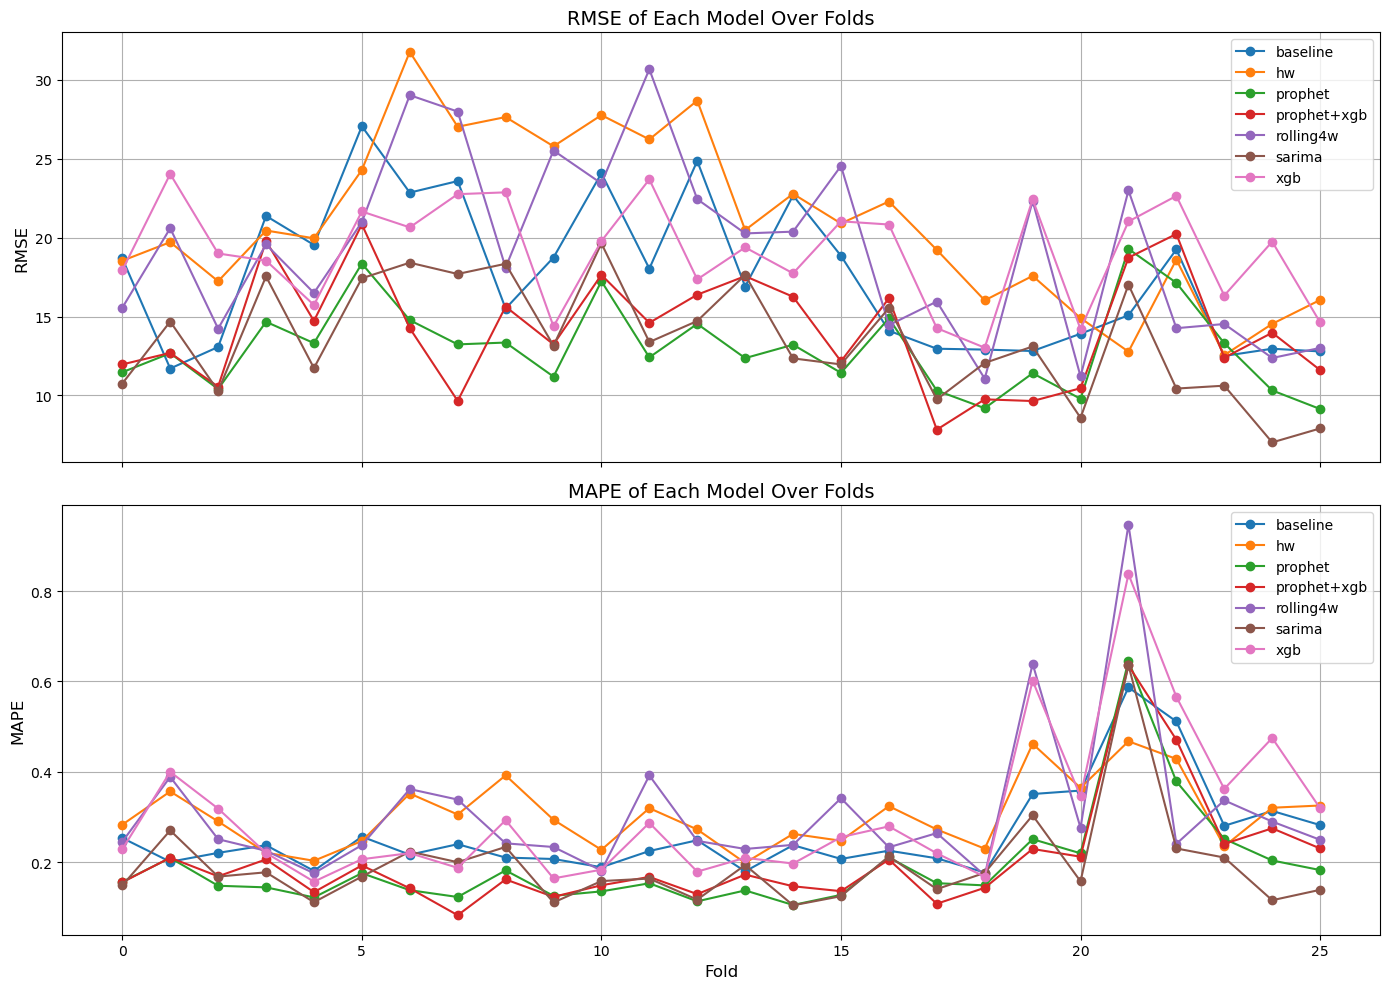

In [57]:
import matplotlib.pyplot as plt

# Make a copy and drop 'mean' row if present
plot_table = final_table.drop(index='mean', errors='ignore')
# Use fold numbers as x-axis
x = plot_table.index

# Create subplots: 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# RMSE
for model in plot_table['rmse'].columns:
    axes[0].plot(x, plot_table['rmse'][model], marker='o', label=model)
axes[0].set_title('RMSE of Each Model Over Folds', fontsize=14)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].legend()
axes[0].grid(True)

# MAPE
for model in plot_table['mape'].columns:
    axes[1].plot(x, plot_table['mape'][model], marker='o', label=model)
axes[1].set_title('MAPE of Each Model Over Folds', fontsize=14)
axes[1].set_ylabel('MAPE', fontsize=12)
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Prophet Models with varying degrees of Initial Data

One might ask if there is too much noise at the start of the data. Afterall, 2020-2021 were still during the years where the effects of the COVID-19 pandemic were being felt. We consider what happens to Prophet's predictions as we drop data before 2020, 2021, 2022, 2023, and 2024. Of course, dropping data before 2020 just corresponds to the results above. We collect the RMSEs and MAPEs into a table and display the results in a markdown cell below at the end of this section. As a preview, we do not end up finding significant improvements in the model by dropping dates before a given year.

## Dropping <2020 data

In [54]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 since there was a leap year
print(len(rs)==2251-366)

date_range = pd.date_range(start="2020-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet20_results_df = pd.DataFrame(results)
prophet20_results_df.loc['mean'] = ['mean',  prophet20_results_df['rmse'].mean(), prophet20_results_df['mape'].mean()]
prophet20_results_df

False


12:14:23 - cmdstanpy - INFO - Chain [1] start processing
12:14:23 - cmdstanpy - INFO - Chain [1] done processing
12:14:24 - cmdstanpy - INFO - Chain [1] start processing
12:14:24 - cmdstanpy - INFO - Chain [1] done processing
12:14:24 - cmdstanpy - INFO - Chain [1] start processing
12:14:25 - cmdstanpy - INFO - Chain [1] done processing
12:14:25 - cmdstanpy - INFO - Chain [1] start processing
12:14:25 - cmdstanpy - INFO - Chain [1] done processing
12:14:26 - cmdstanpy - INFO - Chain [1] start processing
12:14:26 - cmdstanpy - INFO - Chain [1] done processing
12:14:27 - cmdstanpy - INFO - Chain [1] start processing
12:14:27 - cmdstanpy - INFO - Chain [1] done processing
12:14:27 - cmdstanpy - INFO - Chain [1] start processing
12:14:28 - cmdstanpy - INFO - Chain [1] done processing
12:14:28 - cmdstanpy - INFO - Chain [1] start processing
12:14:28 - cmdstanpy - INFO - Chain [1] done processing
12:14:29 - cmdstanpy - INFO - Chain [1] start processing
12:14:29 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,11.394947,0.156058
1,1,12.742627,0.210032
2,2,10.399074,0.149450
3,3,14.913675,0.147294
4,4,13.553925,0.124753
5,5,18.349496,0.175977
6,6,14.608758,0.135860
7,7,13.318272,0.125695
8,8,13.339663,0.182526
9,9,11.258690,0.126271


## Dropping <2021 data

In [55]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2021-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 since there was a leap year
print(len(rs)==2251-366)

date_range = pd.date_range(start="2021-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet21_results_df = pd.DataFrame(results)
prophet21_results_df.loc['mean'] = ['mean',  prophet21_results_df['rmse'].mean(), prophet21_results_df['mape'].mean()]
prophet21_results_df

False


12:14:45 - cmdstanpy - INFO - Chain [1] start processing
12:14:45 - cmdstanpy - INFO - Chain [1] done processing
12:14:45 - cmdstanpy - INFO - Chain [1] start processing
12:14:46 - cmdstanpy - INFO - Chain [1] done processing
12:14:46 - cmdstanpy - INFO - Chain [1] start processing
12:14:46 - cmdstanpy - INFO - Chain [1] done processing
12:14:47 - cmdstanpy - INFO - Chain [1] start processing
12:14:47 - cmdstanpy - INFO - Chain [1] done processing
12:14:47 - cmdstanpy - INFO - Chain [1] start processing
12:14:47 - cmdstanpy - INFO - Chain [1] done processing
12:14:48 - cmdstanpy - INFO - Chain [1] start processing
12:14:48 - cmdstanpy - INFO - Chain [1] done processing
12:14:48 - cmdstanpy - INFO - Chain [1] start processing
12:14:49 - cmdstanpy - INFO - Chain [1] done processing
12:14:49 - cmdstanpy - INFO - Chain [1] start processing
12:14:49 - cmdstanpy - INFO - Chain [1] done processing
12:14:50 - cmdstanpy - INFO - Chain [1] start processing
12:14:50 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,11.207674,0.153805
1,1,16.167075,0.274413
2,2,13.641568,0.209760
3,3,13.099902,0.131128
4,4,12.430593,0.107976
5,5,18.429666,0.180216
6,6,14.009336,0.127237
7,7,12.563304,0.127339
8,8,13.154856,0.172208
9,9,11.594351,0.126229


## Dropping <2022 data

In [56]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2022-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 - 365 since there was a leap year
print(len(rs)==2251-366-365)

date_range = pd.date_range(start="2022-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet22_results_df = pd.DataFrame(results)
prophet22_results_df.loc['mean'] = ['mean',  prophet22_results_df['rmse'].mean(), prophet22_results_df['mape'].mean()]
prophet22_results_df

False


12:15:03 - cmdstanpy - INFO - Chain [1] start processing
12:15:04 - cmdstanpy - INFO - Chain [1] done processing
12:15:04 - cmdstanpy - INFO - Chain [1] start processing
12:15:04 - cmdstanpy - INFO - Chain [1] done processing
12:15:04 - cmdstanpy - INFO - Chain [1] start processing
12:15:05 - cmdstanpy - INFO - Chain [1] done processing
12:15:05 - cmdstanpy - INFO - Chain [1] start processing
12:15:05 - cmdstanpy - INFO - Chain [1] done processing
12:15:05 - cmdstanpy - INFO - Chain [1] start processing
12:15:06 - cmdstanpy - INFO - Chain [1] done processing
12:15:06 - cmdstanpy - INFO - Chain [1] start processing
12:15:06 - cmdstanpy - INFO - Chain [1] done processing
12:15:07 - cmdstanpy - INFO - Chain [1] start processing
12:15:07 - cmdstanpy - INFO - Chain [1] done processing
12:15:07 - cmdstanpy - INFO - Chain [1] start processing
12:15:07 - cmdstanpy - INFO - Chain [1] done processing
12:15:08 - cmdstanpy - INFO - Chain [1] start processing
12:15:08 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,10.660958,0.147555
1,1,15.250839,0.255018
2,2,11.600931,0.171586
3,3,12.868148,0.137454
4,4,11.756828,0.107634
5,5,17.952469,0.174893
6,6,14.775103,0.149112
7,7,12.833472,0.126933
8,8,16.272509,0.215701
9,9,12.101910,0.138425


## Dropping <2023 data

In [57]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2023-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 - 365 since there was a leap year
print(len(rs)==2251-366-365-365)

date_range = pd.date_range(start="2023-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet23_results_df = pd.DataFrame(results)
prophet23_results_df.loc['mean'] = ['mean',  prophet23_results_df['rmse'].mean(), prophet23_results_df['mape'].mean()]
prophet23_results_df

12:15:19 - cmdstanpy - INFO - Chain [1] start processing


False


12:15:19 - cmdstanpy - INFO - Chain [1] done processing
12:15:19 - cmdstanpy - INFO - Chain [1] start processing
12:15:19 - cmdstanpy - INFO - Chain [1] done processing
12:15:20 - cmdstanpy - INFO - Chain [1] start processing
12:15:20 - cmdstanpy - INFO - Chain [1] done processing
12:15:20 - cmdstanpy - INFO - Chain [1] start processing
12:15:20 - cmdstanpy - INFO - Chain [1] done processing
12:15:21 - cmdstanpy - INFO - Chain [1] start processing
12:15:21 - cmdstanpy - INFO - Chain [1] done processing
12:15:21 - cmdstanpy - INFO - Chain [1] start processing
12:15:21 - cmdstanpy - INFO - Chain [1] done processing
12:15:22 - cmdstanpy - INFO - Chain [1] start processing
12:15:22 - cmdstanpy - INFO - Chain [1] done processing
12:15:22 - cmdstanpy - INFO - Chain [1] start processing
12:15:22 - cmdstanpy - INFO - Chain [1] done processing
12:15:22 - cmdstanpy - INFO - Chain [1] start processing
12:15:22 - cmdstanpy - INFO - Chain [1] done processing
12:15:23 - cmdstanpy - INFO - Chain [1] 

,fold,rmse,mape
0,0,18.504403,0.250200
1,1,11.798177,0.185011
2,2,8.838522,0.131783
3,3,23.658235,0.263201
4,4,21.819491,0.228433
5,5,24.117976,0.228511
6,6,15.383262,0.124961
7,7,15.454004,0.160426
8,8,18.457807,0.258060
9,9,11.320829,0.129720


## Dropping <2024 data

In [58]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2024-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 - 365 since there was a leap year
print(len(rs)==2251-366-365-365-366)

date_range = pd.date_range(start="2024-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet24_results_df = pd.DataFrame(results)
prophet24_results_df.loc['mean'] = ['mean',  prophet24_results_df['rmse'].mean(), prophet24_results_df['mape'].mean()]
prophet24_results_df

12:15:32 - cmdstanpy - INFO - Chain [1] start processing


False


12:15:33 - cmdstanpy - INFO - Chain [1] done processing
12:15:33 - cmdstanpy - INFO - Chain [1] start processing
12:15:33 - cmdstanpy - INFO - Chain [1] done processing
12:15:33 - cmdstanpy - INFO - Chain [1] start processing
12:15:34 - cmdstanpy - INFO - Chain [1] done processing
12:15:34 - cmdstanpy - INFO - Chain [1] start processing
12:15:34 - cmdstanpy - INFO - Chain [1] done processing
12:15:35 - cmdstanpy - INFO - Chain [1] start processing
12:15:35 - cmdstanpy - INFO - Chain [1] done processing
12:15:35 - cmdstanpy - INFO - Chain [1] start processing
12:15:35 - cmdstanpy - INFO - Chain [1] done processing
12:15:35 - cmdstanpy - INFO - Chain [1] start processing
12:15:35 - cmdstanpy - INFO - Chain [1] done processing
12:15:35 - cmdstanpy - INFO - Chain [1] start processing
12:15:36 - cmdstanpy - INFO - Chain [1] done processing
12:15:36 - cmdstanpy - INFO - Chain [1] start processing
12:15:36 - cmdstanpy - INFO - Chain [1] done processing
12:15:36 - cmdstanpy - INFO - Chain [1] 

,fold,rmse,mape
0,0,10.937939,0.148404
1,1,15.397247,0.278976
2,2,9.619536,0.164645
3,3,21.468768,0.223606
4,4,18.027764,0.184243
5,5,18.392821,0.171075
6,6,18.996617,0.231326
7,7,18.872277,0.227241
8,8,25.029740,0.357418
9,9,12.983677,0.147696


## Results Table and Conclusion

The results displayed below show that including pre-2020 does not drastically improve Prophet's forecasting performance.

In [59]:
# We make a dictionary of models and their results to make it easier to iterate over. 
# Make sure to add to this if writing new models in.
models = {
    'prophet24': prophet24_results_df,
    'prophet23': prophet23_results_df,
    'prophet22': prophet22_results_df,
    'prophet21': prophet21_results_df,
    'prophet20': prophet20_results_df,
}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

# Put all of the dataframes together into one dataframe for display
final_results_df = pd.concat(all_results, ignore_index=True)
# Make a pivot table so that we display rmse, mape and then each of the models and their results.
final_table = final_results_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table.index = final_table.index.where(final_table.index != '-', 'mean')

final_table

rmse                                                  mape  \
model  prophet20  prophet21  prophet22  prophet23  prophet24 prophet20   
fold                                                                     
0      11.394947  11.207674  10.660958  18.504403  10.937939  0.156058   
1      12.742627  16.167075  15.250839  11.798177  15.397247  0.210032   
2      10.399074  13.641568  11.600931   8.838522   9.619536  0.149450   
3      14.913675  13.099902  12.868148  23.658235  21.468768  0.147294   
4      13.553925  12.430593  11.756828  21.819491  18.027764  0.124753   
5      18.349496  18.429666  17.952469  24.117976  18.392821  0.175977   
6      14.608758  14.009336  14.775103  15.383262  18.996617  0.135860   
7      13.318272  12.563304  12.833472  15.454004  18.872277  0.125695   
8      13.339663  13.154856  16.272509  18.457807  25.029740  0.182526   
9      11.258690  11.594351  12.101910  11.320829  12.983677  0.126271   
10     17.151339  14.597572  14.811283  15.591421  15.430452  0.133903   
11     12.507919  13.229786  15.859813  17.348736  19.121247  0.155195   
12     14.623525  14.280051  12.568072  13.289218  13.061977  0.116326   
13     12.263379  12.872178  12.128636  17.323349  14.945779  0.136620   
14     13.224883  12.683383  13.097751  16.452843  13.980261  0.104869   
15     11.482424  11.312733  12.913203  23.830868  18.787902  0.128303   
16     14.918997  14.291080  12.533273  30.068266  22.401609  0.211404   
17     10.268451  11.105378  10.074862  24.859140  17.506358  0.153490   
18      9.113177   9.174516   9.720959  18.807751   9.769792  0.146653   
19     11.654522  11.244050  11.679284  28.518369  18.132662  0.253311   
20      9.761949  10.230587   9.259645  18.618050   9.475259  0.217958   
21     19.265931  19.247516  19.544720  19.354147  14.392512  0.646481   
22     17.141583  16.146163  16.759013  16.718300  18.482890  0.375666   
23     13.386948  12.240975  13.267604  13.617413  19.910231  0.250413   
24     10.292624   8.865832  12.332497  10.902643  14.893101  0.203581   
25      9.147295   7.131137   8.050195   5.851636  21.965882  0.182399   
mean   13.080157  12.882741  13.102845  17.711725  16.614781  0.190404   

                                               
model prophet21 prophet22 prophet23 prophet24  
fold                                           
0      0.153805  0.147555  0.250200  0.148404  
1      0.274413  0.255018  0.185011  0.278976  
2      0.209760  0.171586  0.131783  0.164645  
3      0.131128  0.137454  0.263201  0.223606  
4      0.107976  0.107634  0.228433  0.184243  
5      0.180216  0.174893  0.228511  0.171075  
6      0.127237  0.149112  0.124961  0.231326  
7      0.127339  0.126933  0.160426  0.227241  
8      0.172208  0.215701  0.258060  0.357418  
9      0.126229  0.138425  0.129720  0.147696  
10     0.122069  0.123770  0.126368  0.126671  
11     0.162968  0.197129  0.217316  0.241863  
12     0.115629  0.112106  0.149400  0.146166  
13     0.145540  0.137891  0.180207  0.159218  
14     0.096302  0.105149  0.205919  0.163607  
15     0.129872  0.151604  0.323598  0.251436  
16     0.195406  0.168914  0.474536  0.339279  
17     0.162092  0.147696  0.423679  0.289213  
18     0.150022  0.157189  0.315857  0.138397  
19     0.261021  0.266883  0.719652  0.457224  
20     0.225916  0.209134  0.463779  0.188702  
21     0.623758  0.618725  0.646931  0.470957  
22     0.354999  0.363460  0.363270  0.370552  
23     0.228045  0.248076  0.254976  0.397181  
24     0.173585  0.246182  0.222143  0.341561  
25     0.132781  0.154208  0.095760  0.474792  
mean   0.188089  0.193555  0.274758  0.257363

The results above above indicate that the Prophet model *does not* on average improve significantly as we start dropping data before a given year. We can see this in some folds e.g. fold 0, 1, 2. We also see that there are some folds where the RMSE basically stays the same. Then there are folds like folds 15 and 11 where things seem to improve by dropping some years. The best average RMSE, however, does occur if we drop all pre-2022 data though the improvement is very minor. One might hypothesize that this was due to the lfiting of COVID-19 lockdowns.